# 📊 Visualización Estática de Datos con Python - Gráficos de Barras
Este notebook contiene la implementación práctica y comparativa para la creación de gráficos de barras usando **Matplotlib**, **Pandas** y **Seaborn**, utilizando las estructuras de datos tratadas en la sesión.

In [6]:
# Configuración inicial e importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo global
sns.set_theme(style="whitegrid")

## 1. Gráficos de Barras para Medidas de Resumen

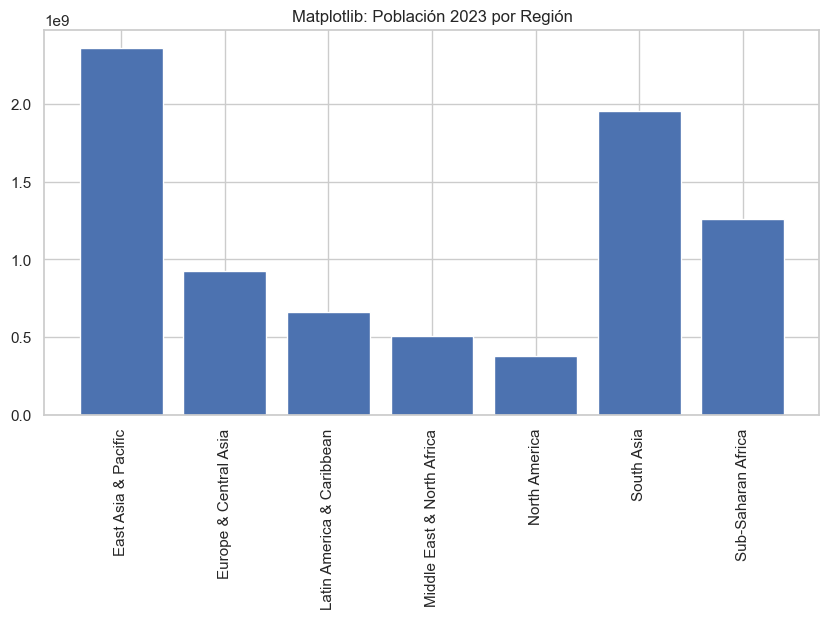

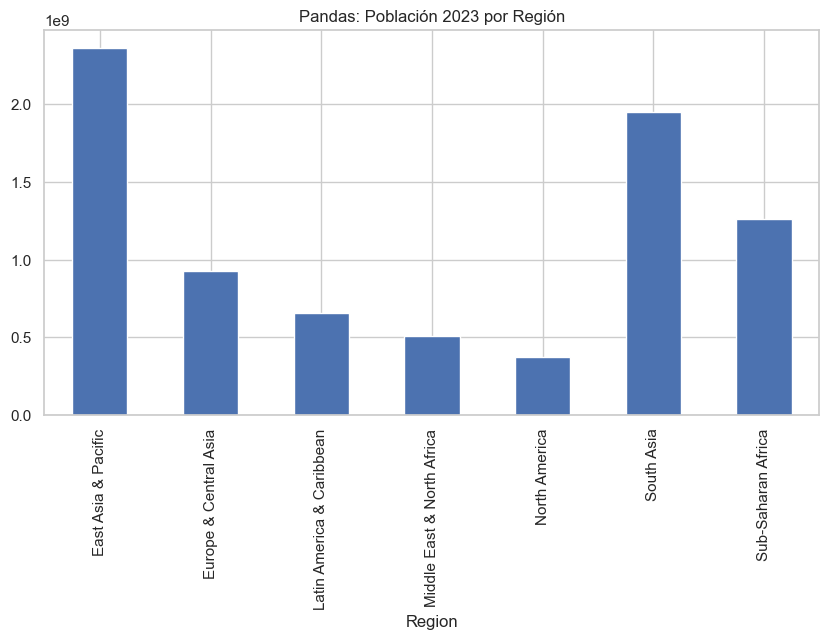

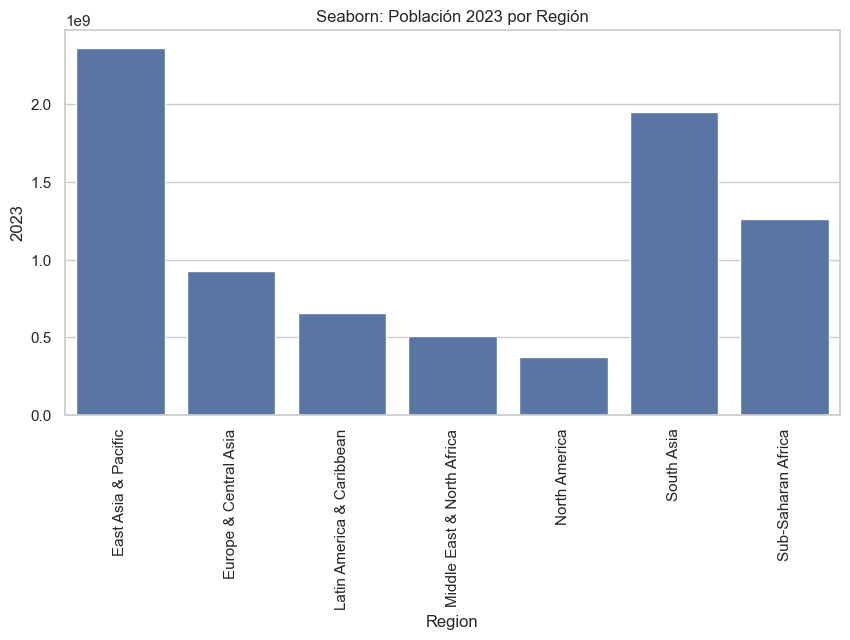

In [7]:
population = pd.read_csv('2.0 Population.csv')
metadata = pd.read_csv('2.0 Metadata.csv')
merged_df = population.merge(metadata, on='Country Code')


region_population = merged_df[['Region', '2023']].groupby('Region').sum()

# --- MATPLOTLIB ---
plt.figure(figsize=(10, 5))
plt.bar(region_population.index, region_population['2023'])
plt.xticks(rotation=90)
plt.title("Matplotlib: Población 2023 por Región")
plt.show()

# --- PANDAS ---
region_population['2023'].plot(kind='bar', figsize=(10, 5), title="Pandas: Población 2023 por Región")
plt.xticks(rotation=90)
plt.show()

# --- SEABORN ---
plt.figure(figsize=(10, 5))
sns.barplot(x=region_population.index, y=region_population['2023'])
plt.xticks(rotation=90)
plt.title("Seaborn: Población 2023 por Región")
plt.show()

## 2. Aplicación de Colores y Paletas

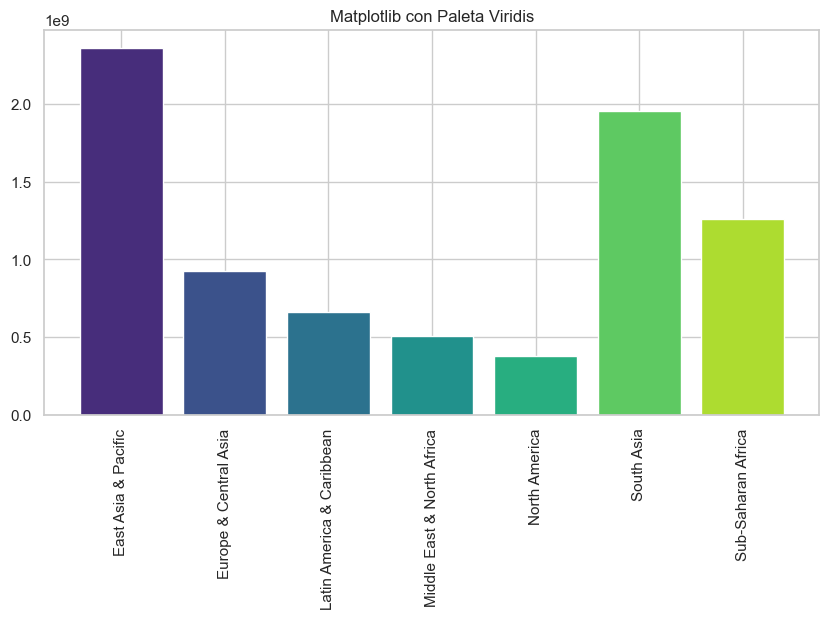

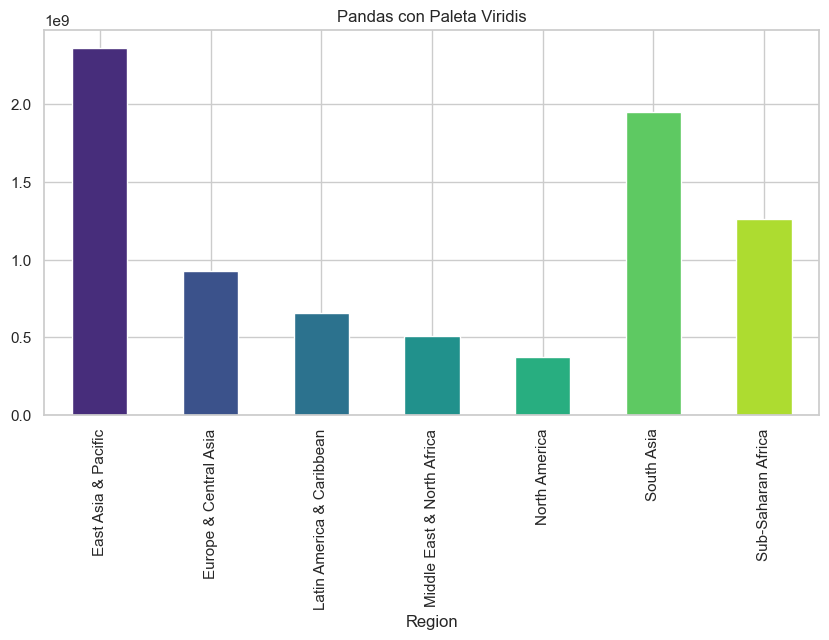

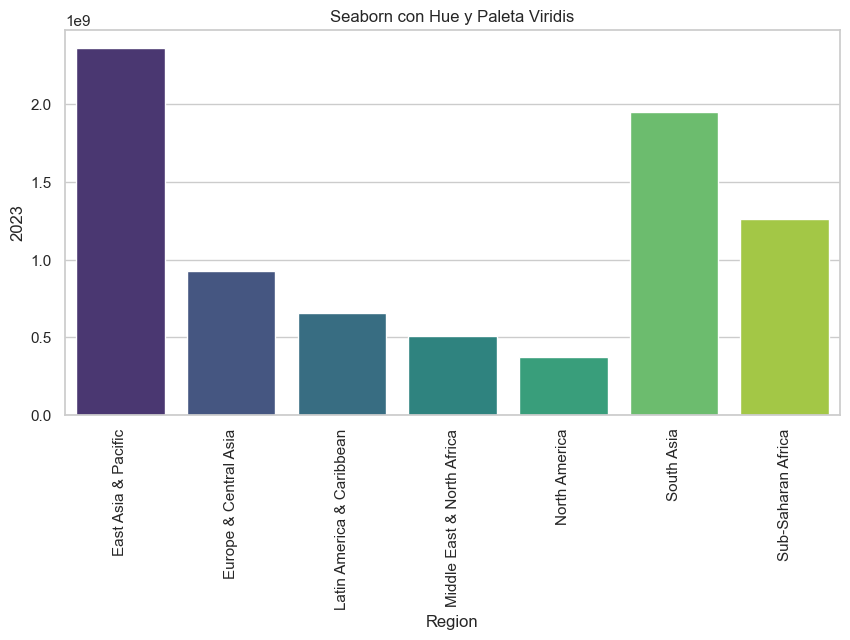

In [8]:
# --- MATPLOTLIB ---
plt.figure(figsize=(10, 5))
colors = sns.color_palette('viridis', n_colors=len(region_population))
plt.bar(region_population.index, region_population['2023'], color=colors)
plt.xticks(rotation=90)
plt.title("Matplotlib con Paleta Viridis")
plt.show()

# --- PANDAS ---
colors = sns.color_palette('viridis', n_colors=len(region_population))
region_population['2023'].plot(kind='bar', color=colors, figsize=(10, 5), title="Pandas con Paleta Viridis")
plt.xticks(rotation=90)
plt.show()

# --- SEABORN ---
plt.figure(figsize=(10, 5))
sns.barplot(
    x=region_population.index, 
    y=region_population['2023'], 
    hue=region_population.index, 
    palette='viridis'
)
plt.xticks(rotation=90)
plt.title("Seaborn con Hue y Paleta Viridis")
plt.show()

## 3. Gráficos de Barras Horizontales

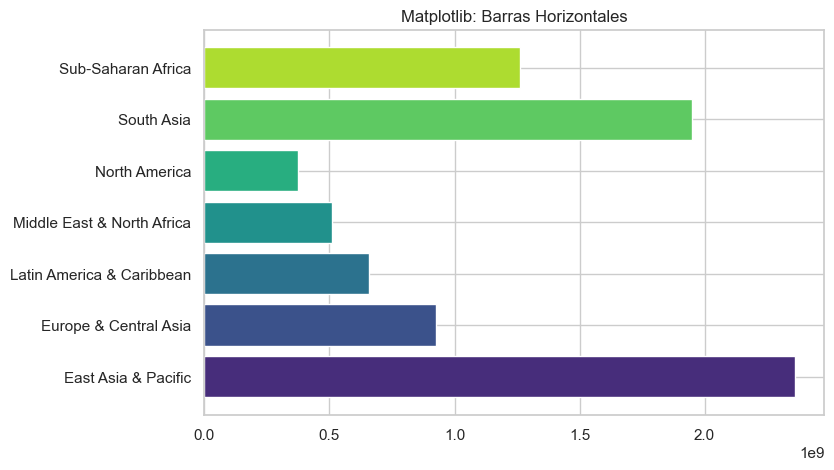

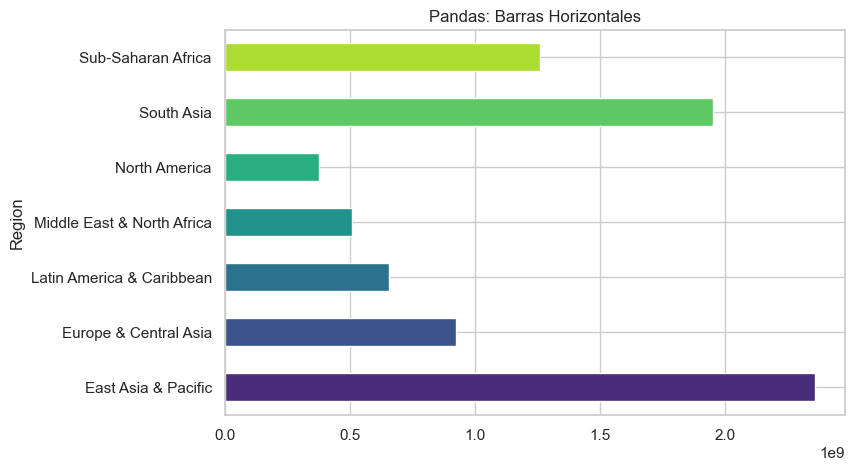

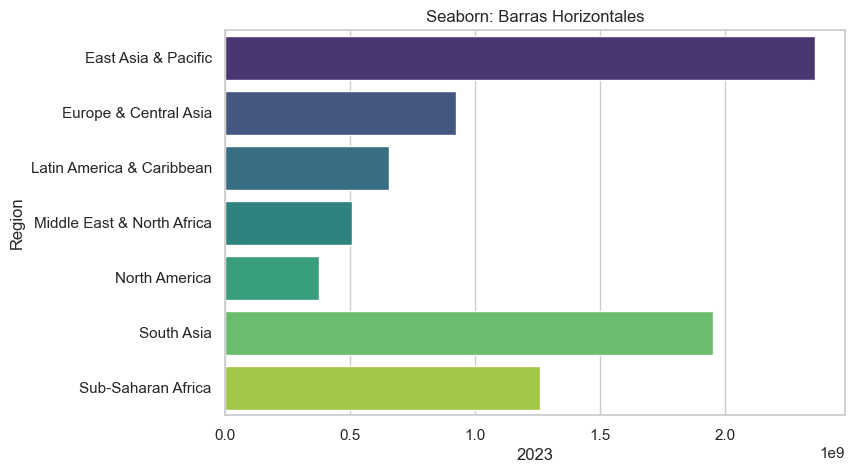

In [9]:
# --- MATPLOTLIB ---
plt.figure(figsize=(8, 5))
colors = sns.color_palette('viridis', n_colors=len(region_population))
plt.barh(region_population.index, region_population['2023'], color=colors)
plt.title("Matplotlib: Barras Horizontales")
plt.show()

# --- PANDAS ---
region_population['2023'].plot(kind='barh', color=colors, figsize=(8, 5), title="Pandas: Barras Horizontales")
plt.show()

# --- SEABORN ---
plt.figure(figsize=(8, 5))
sns.barplot(
    y=region_population.index, 
    x=region_population['2023'], 
    hue=region_population.index, 
    palette='viridis', 
    orient='h'
)
plt.title("Seaborn: Barras Horizontales")
plt.show()

## 4. Agrupación Semántica (Variables Bivariadas)

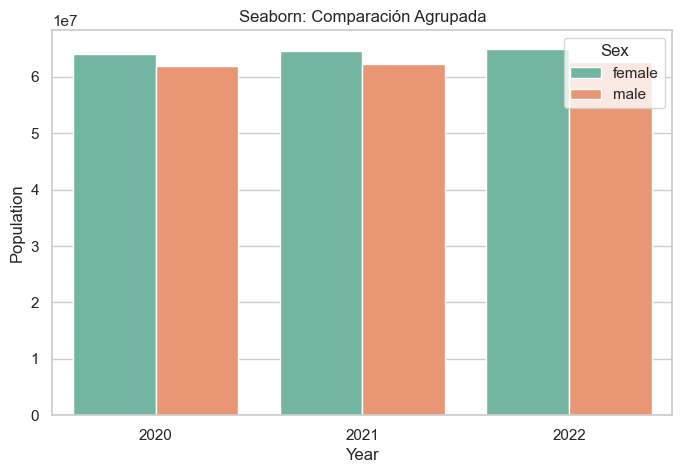

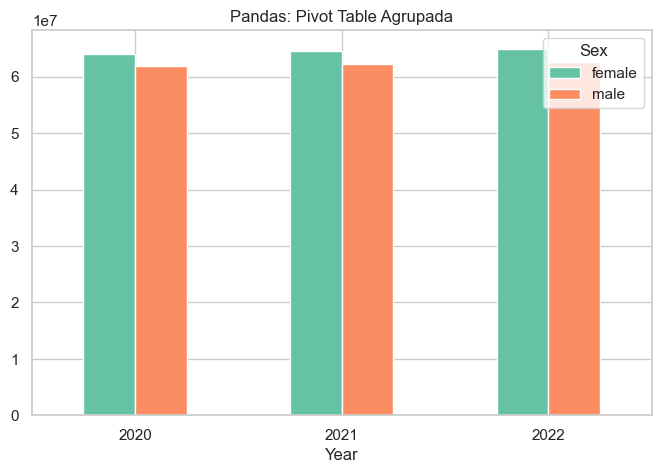

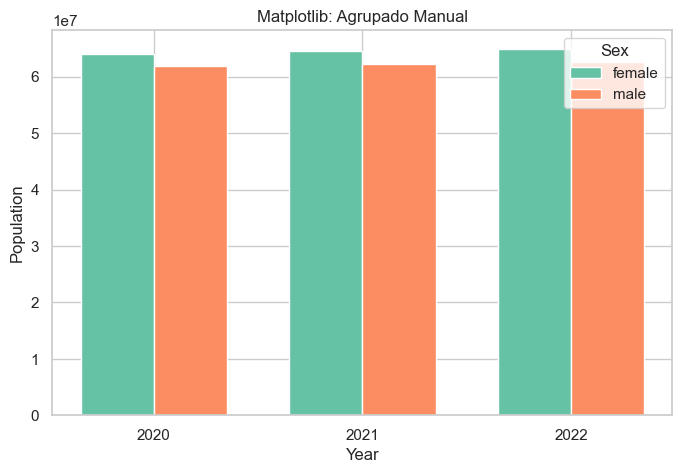

In [10]:
# Estructura de ejemplo basada en gender_mex (Población por Año y Sexo)
data_gender = {
    'Year': [2020, 2020, 2021, 2021, 2022, 2022],
    'Sex': ['female', 'male', 'female', 'male', 'female', 'male'],
    'Population': [64000000, 62000000, 64500000, 62300000, 65000000, 62600000]
}
gender_mex = pd.DataFrame(data_gender)

# --- SEABORN (Directo con hue) ---
plt.figure(figsize=(8, 5))
sns.set_palette('Set2')
sns.barplot(x='Year', y='Population', hue='Sex', data=gender_mex)
plt.title("Seaborn: Comparación Agrupada")
plt.show()

# --- PANDAS (Requiere .pivot()) ---
pivot_df = gender_mex.pivot(index='Year', columns='Sex', values='Population')
pivot_df.plot(kind='bar', figsize=(8, 5), title="Pandas: Pivot Table Agrupada")
plt.xticks(rotation=0)
plt.show()

# --- MATPLOTLIB (Desplazamiento manual) ---
plt.figure(figsize=(8, 5))
x = np.arange(len(pivot_df.index))
width = 0.35

plt.bar(x - width/2, pivot_df['female'], width, label='female')
plt.bar(x + width/2, pivot_df['male'], width, label='male')
plt.xticks(ticks=x, labels=pivot_df.index)
plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Matplotlib: Agrupado Manual")
plt.legend(title='Sex')
plt.show()

## 5. Gráficos de Conteo o Frecuencia

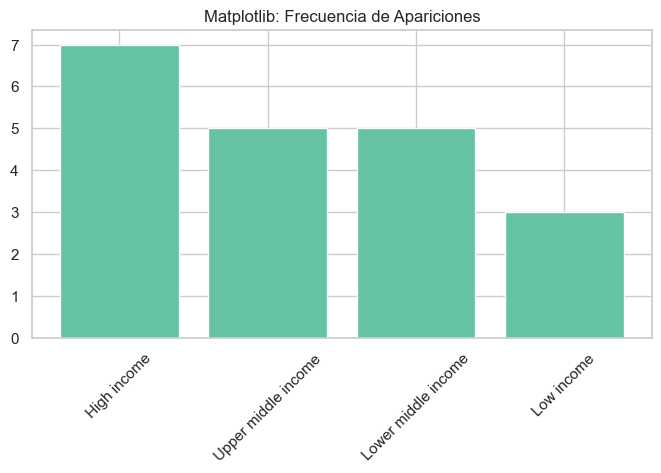

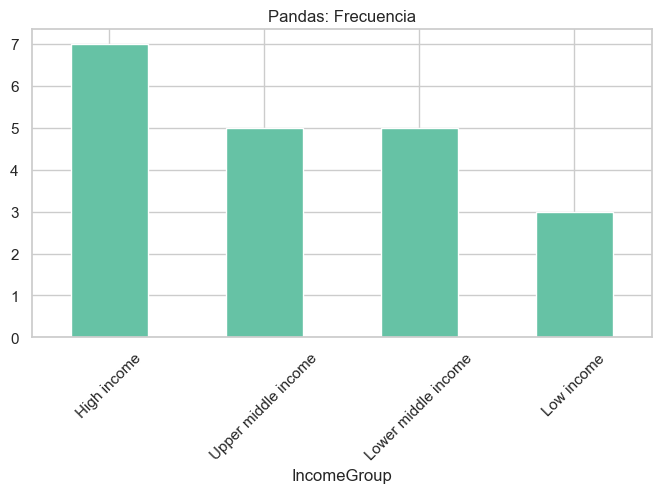

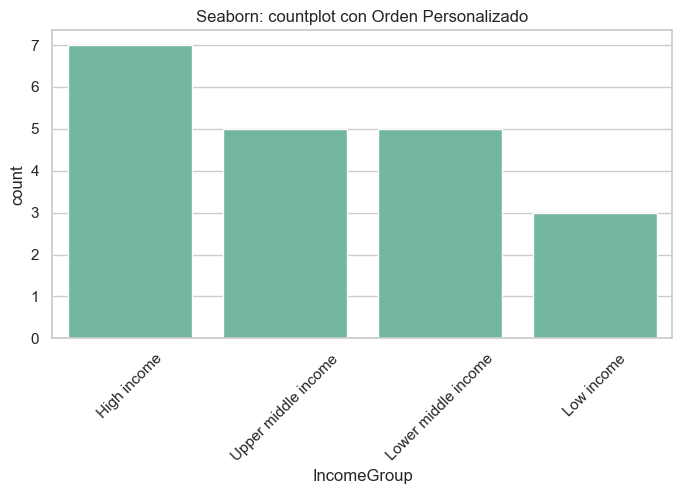

: 

In [ ]:
# Estructura de ejemplo basada en metadata (IncomeGroup)
data_meta = {
    'Country': [f'Country_{i}' for i in range(20)],
    'IncomeGroup': ['High income', 'Low income', 'Upper middle income', 'High income', 
                   'Lower middle income', 'High income', 'Upper middle income', 'Low income',
                   'Lower middle income', 'High income', 'Upper middle income', 'High income',
                   'Lower middle income', 'Low income', 'High income', 'Upper middle income',
                   'Lower middle income', 'High income', 'Upper middle income', 'Lower middle income']
}
metadata = pd.DataFrame(data_meta)

# --- MATPLOTLIB ---
plt.figure(figsize=(8, 4))
counts = metadata['IncomeGroup'].value_counts()
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45)
plt.title("Matplotlib: Frecuencia de Apariciones")
plt.show()

# --- PANDAS ---
metadata['IncomeGroup'].value_counts().plot(kind='bar', figsize=(8, 4), title="Pandas: Frecuencia")
plt.xticks(rotation=45)
plt.show()

# --- SEABORN (countplot) ---
plt.figure(figsize=(8, 4))
order_list = metadata['IncomeGroup'].value_counts().index
sns.countplot(x='IncomeGroup', data=metadata, order=order_list)
plt.xticks(rotation=45)
plt.title("Seaborn: countplot con Orden Personalizado")
plt.show()